# **Import Libraries**

In [1]:
# How can we improve fleet efficiency and revenue?
# **Problem Statement:**
# Questions:

# Demand forecasting
# Peak-hour prediction
# Route optimization
# Driver performance

# Skills:

# Time Series
# Geospatial Analytics
# Deep Learning Forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
import zipfile
import os

zip_file_path = "nyc-taxi-trip-duration.zip"

extract_folder = "nyc-taxi-trip-duration"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
    print("Files extracted successfully.")

Files extracted successfully.


In [3]:
df = pd.read_csv("nyc-taxi-trip-duration/train.zip", compression='zip')
df.head(10)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443
6,id1813257,1,2016-06-17 22:34:59,2016-06-17 22:40:40,4,-73.969017,40.757839,-73.957405,40.765896,N,341
7,id1324603,2,2016-05-21 07:54:58,2016-05-21 08:20:49,1,-73.969276,40.797779,-73.922470,40.760559,N,1551
8,id1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,N,255
9,id0012891,2,2016-03-10 21:45:01,2016-03-10 22:05:26,1,-73.981049,40.744339,-73.973000,40.789989,N,1225


In [4]:
df.shape

(1458644, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 189.2 MB


In [6]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [8]:
df['trip_duration_min'] = df['trip_duration'] / 60

In [9]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_min
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000


In [10]:
#Time Range
df['pickup_datetime'].min()

'2016-01-01 00:00:17'

In [1]:
df['pickup_datetime'].max()

NameError: name 'df' is not defined

In [12]:
print(df.columns)

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'trip_duration_min'],
      dtype='str')


<Axes: >

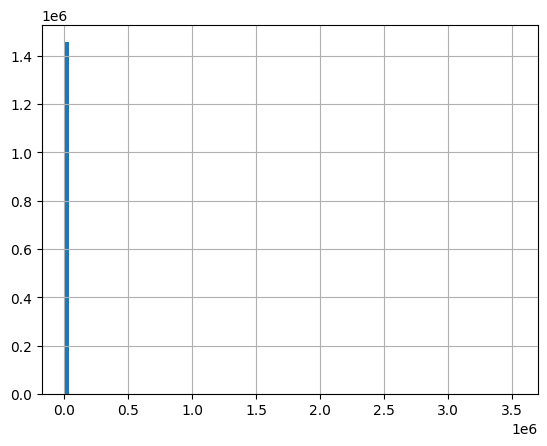

In [13]:
df['trip_duration'].hist(bins=100)

In [14]:
(df['passenger_count'] == 0).mean()*100

np.float64(0.0041134094405488935)

In [15]:
df.groupby(df['passenger_count'] == 0)['trip_duration_min'].mean()

passenger_count
False    15.991018
True     28.640556
Name: trip_duration_min, dtype: float64

In [16]:
df.groupby(df['passenger_count'] == 0)['trip_duration_min'].median()

passenger_count
False    11.033333
True      0.341667
Name: trip_duration_min, dtype: float64

In [17]:
df['trip_duration_min'].quantile([0.90,0.95,0.99,0.999])

0.900      27.233333
0.950      35.066667
0.990      57.333333
0.999    1418.805950
Name: trip_duration_min, dtype: float64

In [18]:
(df['trip_duration_min'] > 57).sum()

np.int64(14900)

In [19]:
(df['trip_duration_min'] > 1418).sum()

np.int64(1474)

In [20]:
df.nlargest(10, 'trip_duration')[['trip_duration','vendor_id', 'pickup_datetime', 'dropoff_datetime']]

,trip_duration,vendor_id,pickup_datetime,dropoff_datetime
978383,3526282,1,2016-02-13 22:46:52,2016-03-25 18:18:14
924150,2227612,1,2016-01-05 06:14:15,2016-01-31 01:01:07
680594,2049578,1,2016-02-13 22:38:00,2016-03-08 15:57:38
355003,1939736,1,2016-01-05 00:19:42,2016-01-27 11:08:38
1234291,86392,2,2016-02-15 23:18:06,2016-02-16 23:17:58
295382,86391,2,2016-05-31 13:00:39,2016-06-01 13:00:30
73816,86390,2,2016-05-06 00:00:10,2016-05-07 00:00:00
59891,86387,2,2016-06-30 16:37:52,2016-07-01 16:37:39
1360439,86385,2,2016-06-23 16:01:45,2016-06-24 16:01:30
753765,86379,2,2016-05-17 22:22:56,2016-05-18 22:22:35


In [21]:
(df['trip_duration'] > 3440).sum()

np.int64(14575)

In [22]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [23]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour

In [24]:
df.groupby('pickup_hour')['trip_duration_min'].median()

pickup_hour
0     10.766667
1     10.216667
2      9.850000
3      9.866667
4     10.183333
5      8.616667
6      7.883333
7      9.583333
8     11.000000
9     11.333333
10    11.316667
11    11.716667
12    11.766667
13    11.833333
14    12.100000
15    12.000000
16    11.583333
17    11.683333
18    11.450000
19    10.800000
20    10.566667
21    10.700000
22    11.133333
23    11.166667
Name: trip_duration_min, dtype: float64

In [25]:
# Pickup Day Feature Function

def create_pickup_day(df):
    """
    Create pickup_day feature for pickup_datetime.

    Return:
        DataFrame with pickup day column
    """

    df = df.copy()

    df['pickup_day'] = (
        pd.to_datetime(df['pickup_datetime']).dt.day_name()
    )

    return df

In [28]:
df = create_pickup_day(df)

df[['pickup_datetime', 'pickup_day']].head()

,pickup_datetime,pickup_day
0,2016-03-14 17:24:55,Monday
1,2016-06-12 00:43:35,Sunday
2,2016-01-19 11:35:24,Tuesday
3,2016-04-06 19:32:31,Wednesday
4,2016-03-26 13:30:55,Saturday


In [29]:
df['pickup_day'].value_counts()

pickup_day
Friday       223533
Saturday     220868
Thursday     218574
Wednesday    210136
Tuesday      202749
Sunday       195366
Monday       187418
Name: count, dtype: int64

In [26]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_min,pickup_hour
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333,17
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000,11
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000,19
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000,13


In [ ]:
# Step B: Code Editors (VS Code / PyCharm / Scripts)
# Once the data scientist figures out exactly how to clean the data and build the model, they move the functions out of the notebook.

# They copy the clean functions (like create_pickup_day) into a standard Python file, usually named something like clean_data.py or pipeline.py.

# This Python file is what gets deployed to production (e.g., running automatically on AWS, Azure, or Google Cloud) to process new data every day.

# Summary: You use Jupyter Notebooks to explore the data using one-liners like df.info(). Once you decide how to change the data, you write functions, package them into a .py script, and that script becomes your official, automated data pipeline.